<a href="https://colab.research.google.com/github/DhimanTarafdar/AAA/blob/main/Inception_V1_V3ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ১. সমস্যার শুরু — আগের Model গুলোতে কী সমস্যা ছিল

আগের বড় model যেমন VGG16 এবং AlexNet এ বড় বড় convolution filter ব্যবহার হতো — যেমন 3x3, 5x5, এমনকি 7x7। যখন একটা layer এ channel সংখ্যা বেশি থাকে এবং filter size বড় হয়, তখন parameter এর সংখ্যা অস্বাভাবিক রকম বেড়ে যায়।

Parameter বেশি হলে তিনটা বড় সমস্যা হয়:

- **Overfitting** — model training data মুখস্থ করে ফেলে, নতুন data তে ভালো কাজ করে না
- **Memory সমস্যা** — GPU তে রাখতে অনেক বেশি memory লাগে
- **Training ধীর হয়** — প্রতিটা epoch এ বেশি computation লাগে
তখন প্রশ্ন আসলো — একই কাজ কি কম parameter এ করা সম্ভব?

---

## ২. Channel মানে কী

RGB image এ 3টা channel থাকে — Red, Green, Blue। প্রতিটা channel একটা আলাদা 2D map যেখানে pixel এর intensity মান থাকে।

Convolution layer দিয়ে feature extract হওয়ার পর output এও channel তৈরি হয়, কিন্তু এগুলো আর RGB না — এগুলো feature map। একটা channel edge detect করে, আরেকটা texture ধরে, আরেকটা shape এর pattern ধরে। Network যত গভীরে যায়, channel গুলো তত complex feature ধরে।

VGG16 এ শেষের দিকে 512টা channel পর্যন্ত চলে যায়।

---

## ৩. VGG16 এর Approach এবং সমস্যা

VGG16 পুরোটা জুড়ে শুধু 3x3 filter ব্যবহার করেছে। দুটো 3x3 filter পরপর দিলে একটা 5x5 filter এর সমান receptive field পাওয়া যায় কিন্তু parameter কম লাগে — এটা ছিল তখনকার নতুন ধারণা।

**কিন্তু সমস্যা হলো channel সংখ্যায়।**

512 channel এ 3x3 filter চালিয়ে 512 channel output চাইলে:
- Parameter = 3 × 3 × 512 × 512 = **2,359,296** — প্রায় ২৩ লাখ শুধু একটা layer এ
এরকম layer অনেকগুলো মিলিয়ে VGG16 এর মোট parameter দাঁড়ায় প্রায় **138 million** (১৩ কোটি ৮০ লাখ)।

**আরেকটা বড় সমস্যা** — প্রতিটা layer এ একটাই নির্দিষ্ট filter size। Network নিজে সিদ্ধান্ত নিতে পারে না যে এই জায়গায় ছোট feature দরকার নাকি বড় feature দরকার।

---

## ৪. ResNet50 এর Approach এবং সীমাবদ্ধতা

ResNet50 ও মূলত 3x3 filter ব্যবহার করে। কিন্তু প্রতিটা Residual Block এ একটা চালাক কাজ আছে — **Bottleneck**।

প্রতিটা block এ তিনটা layer:
1. **1x1 convolution** দিয়ে channel কমাও
2. **3x3 convolution** দিয়ে feature extract করো
3. **1x1 convolution** দিয়ে channel আবার বাড়িয়ে আগের জায়গায় ফেরাও
এই কারণে ResNet50 এর parameter VGG16 এর চেয়ে অনেক কম — প্রায় **25 million**।

**তবুও সীমাবদ্ধতা আছে** — প্রতিটা layer এ filter size আগে থেকে ঠিক করা। Network নিজে বেছে নিতে পারে না।

---

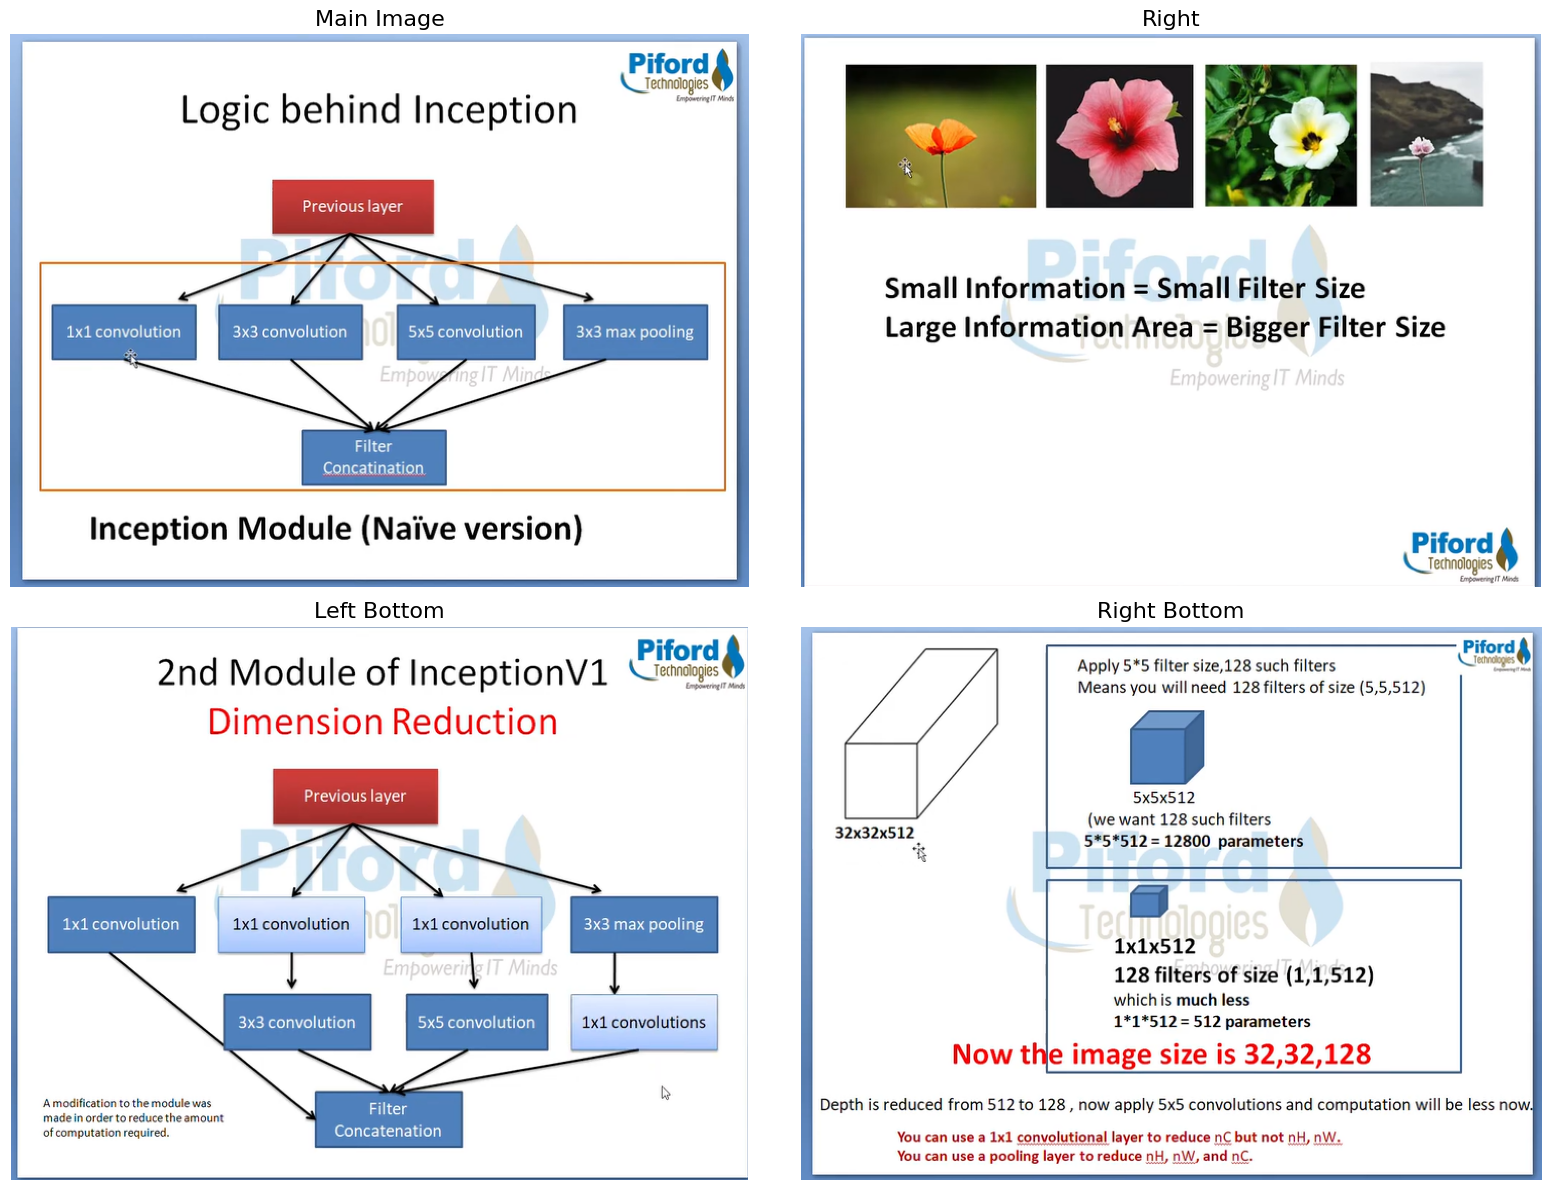

In [4]:
from matplotlib import pyplot as plt
from PIL import Image

# Load images
main_img = Image.open('/content/Screenshot 2026-05-03 231941.png')
right_img = Image.open('/content/Screenshot 2026-05-03 231955.png')
left_bottom_img = Image.open('/content/Screenshot 2026-05-03 232048.png')
right_bottom_img = Image.open('/content/Screenshot 2026-05-03 232112.png')

# Bigger figure size
fig = plt.figure(figsize=(16,12))

# Main image
plt.subplot(2,2,1)
plt.imshow(main_img)
plt.axis('off')
plt.title("Main Image", fontsize=16)

# Right image
plt.subplot(2,2,2)
plt.imshow(right_img)
plt.axis('off')
plt.title("Right", fontsize=16)

# Left bottom image
plt.subplot(2,2,3)
plt.imshow(left_bottom_img)
plt.axis('off')
plt.title("Left Bottom", fontsize=16)

# Right bottom image
plt.subplot(2,2,4)
plt.imshow(right_bottom_img)
plt.axis('off')
plt.title("Right Bottom", fontsize=16)

# Space adjustment
plt.tight_layout()

plt.show()

## ৫. 1x1 Convolution — Inception এর মূল হাতিয়ার

1x1 convolution দেখতে অদ্ভুত মনে হয়, কারণ 1x1 filter দিয়ে spatial feature extract হয় না। কিন্তু এর কাজ আলাদা।

**1x1 convolution এর কাজ হলো channel সংখ্যা কমানো — এটাকে বলে Dimensionality Reduction।**

প্রতিটা pixel এর সব channel এর information একসাথে দেখে একটা নতুন compressed representation তৈরি করে। Information এর সারমর্মটুকু রেখে বাকিটা ছেঁটে ফেলে।

**Parameter তুলনা — 5x5 convolution এর আগে 1x1 বসালে:**

সরাসরি 5x5 (512 → 512 channel):
- Parameter = 5 × 5 × 512 × 512 = **6,553,600** (প্রায় ৬৫ লাখ)
1x1 দিয়ে 512 → 64 channel, তারপর 5x5 (64 → 512 channel):
- 1x1 parameter = 1 × 1 × 512 × 64 = 32,768
- 5x5 parameter = 5 × 5 × 64 × 512 = 819,200
- মোট = **851,968** (প্রায় সাড়ে ৮ লাখ)
**ফলাফল: প্রায় ৮ গুণ কম parameter দিয়ে একই কাজ।**

---